In [37]:
# =========================================
# 1. IMPORT LIBRARIES
# =========================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

In [38]:
# =========================================
# 2. LOAD DATA
# =========================================

# Load Excel dataset
data = pd.read_excel(r"../df.xlsx")

# Remove unwanted rows (adjust if needed)
df = data.iloc[27:, :]

# Ensure data is in time order
df = df.sort_values("Date")

# Set date as index
df.set_index("Date", inplace=True)

# Select time series column
ts = df["Production"]

In [39]:
# =========================================
# 3. TRAIN / VALIDATION / TEST SPLIT
# =========================================

train_size = int(len(ts) * 0.7)
val_size = int(len(ts) * 0.1)
test_size = int(len(ts)*0.2)
train = ts.iloc[:train_size]
validation = ts.iloc[train_size:train_size + val_size]
test = ts.iloc[train_size:]

In [40]:
# =========================================
# 4. NORMALIZATION (VERY IMPORTANT)
# =========================================

scaler = MinMaxScaler(feature_range=(-1, 1))

# Fit ONLY on training data (avoids data leakage)
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))
validation_scaled = scaler.transform(validation.values.reshape(-1, 1))
test_scaled = scaler.transform(test.values.reshape(-1, 1))

# Convert to PyTorch tensors
train_scaled = torch.FloatTensor(train_scaled).view(-1)
validation_scaled = torch.FloatTensor(validation_scaled).view(-1)
test_scaled = torch.FloatTensor(test_scaled).view(-1)

In [41]:
# =========================================
# 5. CREATE SEQUENCES (SLIDING WINDOW)
# =========================================

# LSTM needs input-output pairs like:
# [t1, t2, t3, t4] → t5

def create_sequences(data, seq_len):
    sequences = []
    for i in range(len(data) - seq_len):
        x = data[i:i+seq_len]
        y = data[i+seq_len:i+seq_len+1]
        sequences.append((x, y))
    return sequences


seq_len = 5

train_seq = create_sequences(train_scaled, seq_len)
val_seq = create_sequences(validation_scaled, seq_len)

In [42]:
# =========================================
# 6. BUILD LSTM MODEL
# =========================================

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, output_size=1):
        super().__init__()

        # LSTM layer
        self.lstm = nn.LSTM(input_size, hidden_size)

        # Fully connected layer
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):

        # reshape input for LSTM
        x = x.view(len(x), 1, -1)

        lstm_out, _ = self.lstm(x)

        # take last output
        out = self.fc(lstm_out[-1])

        return out


model = LSTMModel()

loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [43]:
# =========================================
# 7. TRAINING + VALIDATION LOOP
# =========================================

epochs = 80

train_losses = []
val_losses = []

for epoch in range(epochs):

    # ----------------------
    # TRAINING
    # ----------------------
    model.train()
    train_loss = 0

    for seq, label in train_seq:

        optimizer.zero_grad()

        y_pred = model(seq)

        loss = loss_fn(y_pred, label)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_losses.append(train_loss / len(train_seq))


    # ----------------------
    # VALIDATION
    # ----------------------
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for seq, label in val_seq:
            y_pred = model(seq)
            loss = loss_fn(y_pred, label)
            val_loss += loss.item()

    val_losses.append(val_loss / len(val_seq))


    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_losses[-1]:.6f} | "
          f"Val Loss: {val_losses[-1]:.6f}")

C:\Users\User\AppData\Roaming\Python\Python314\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 1/80 | Train Loss: 0.309023 | Val Loss: 0.445756
Epoch 2/80 | Train Loss: 0.264943 | Val Loss: 0.449053
Epoch 3/80 | Train Loss: 0.254915 | Val Loss: 0.434172
Epoch 4/80 | Train Loss: 0.244844 | Val Loss: 0.412162
Epoch 5/80 | Train Loss: 0.230679 | Val Loss: 0.384365
Epoch 6/80 | Train Loss: 0.208278 | Val Loss: 0.356496
Epoch 7/80 | Train Loss: 0.170650 | Val Loss: 0.328015
Epoch 8/80 | Train Loss: 0.102942 | Val Loss: 0.195993
Epoch 9/80 | Train Loss: 0.097099 | Val Loss: 0.187131
Epoch 10/80 | Train Loss: 0.083578 | Val Loss: 0.138762
Epoch 11/80 | Train Loss: 0.081687 | Val Loss: 0.114225
Epoch 12/80 | Train Loss: 0.078326 | Val Loss: 0.091393
Epoch 13/80 | Train Loss: 0.076098 | Val Loss: 0.074104
Epoch 14/80 | Train Loss: 0.074226 | Val Loss: 0.060635
Epoch 15/80 | Train Loss: 0.072684 | Val Loss: 0.050342
Epoch 16/80 | Train Loss: 0.071385 | Val Loss: 0.042438
Epoch 17/80 | Train Loss: 0.070267 | Val Loss: 0.036289
Epoch 18/80 | Train Loss: 0.069284 | Val Loss: 0.031408
E

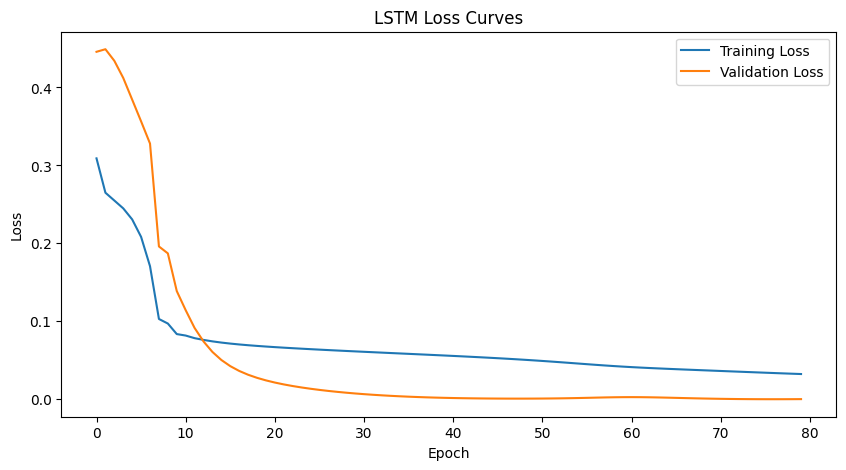

In [44]:
# =========================================
# 8. LOSS CURVES
# =========================================

plt.figure(figsize=(10,5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("LSTM Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

The training and validation loss curves show a steady decrease over epochs, indicating that the LSTM model effectively learned the underlying temporal patterns. The absence of divergence between the curves suggests that the model does not suffer from significant overfitting and generalizes well to unseen data. The model stabilizes after approximately 20–30 epochs.

In [45]:
# =========================================
# 9. FORECASTING (TEST DATA)
# =========================================

model.eval()

predictions = []

input_seq = train_scaled[-seq_len:].clone()

with torch.no_grad():

    for i in range(len(test)):

        y_pred = model(input_seq)

        predictions.append(y_pred.item())

        # update sequence (sliding window)
        input_seq = torch.cat((input_seq[1:], y_pred.view(1)))

In [46]:
# =========================================
# 10. INVERSE TRANSFORM
# =========================================

predictions = np.array(predictions).reshape(-1, 1)
predictions = scaler.inverse_transform(predictions)

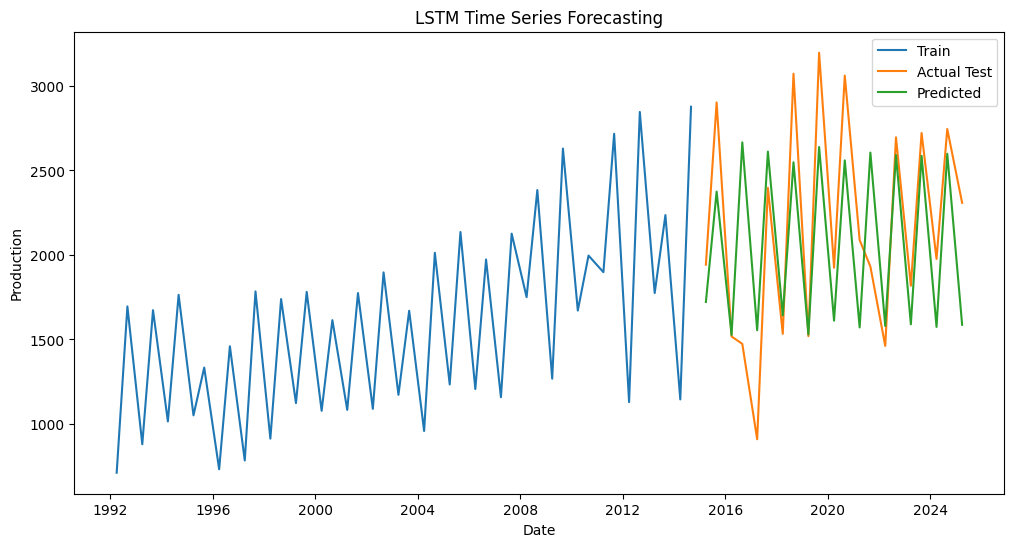

In [47]:
# =========================================
# 11. PLOT RESULTS
# =========================================

plt.figure(figsize=(12,6))

plt.plot(train.index, train.values, label="Train")
# plt.plot(validation.index, validation.values, label="Validation")
plt.plot(test.index, test.values, label="Actual Test")
plt.plot(test.index, predictions, label="Predicted")

plt.title("LSTM Time Series Forecasting")
plt.xlabel("Date")
plt.ylabel("Production")
plt.legend()
plt.show()

In [48]:
# =========================================
# 12. MODEL EVALUATION
# =========================================

y_true = test.values
y_pred = predictions.reshape(-1)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
r2 = r2_score(y_true, y_pred)

print("\n===== MODEL PERFORMANCE =====")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")


===== MODEL PERFORMANCE =====
MAE  : 374.9307
RMSE : 472.1105
MAPE : 19.62%
R²   : 0.4391
